In [1]:
# DecesionTree
# import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder


In [2]:
# read the veteran dataset
df = pd.read_csv('PreProcesseddataset_ifn580_262_v1.csv')

# show all columns information
print(df.convert_dtypes().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  Int64
 1   passanger             12684 non-null  Int64
 2   weather               12684 non-null  Int64
 3   temperature           12684 non-null  Int64
 4   time                  12684 non-null  Int64
 5   coupon                12684 non-null  Int64
 6   expiration            12684 non-null  Int64
 7   gender                12684 non-null  Int64
 8   age                   12684 non-null  Int64
 9   maritalStatus         12684 non-null  Int64
 10  has_children          12684 non-null  Int64
 11  education             12684 non-null  Int64
 12  occupation            12684 non-null  Int64
 13  income                12684 non-null  Int64
 14  Bar                   12684 non-null  Int64
 15  CoffeeHouse           12684 non-null  Int64
 16  Carr

In [3]:
# our goal is is_accepted
# Obtain a list of labels (targets) for each of the samples. We refer to this as 'y'.
y = df["is_accepted"].values
# Remove the label (target) from the samples, as this is not a feature that we want to use to predict against.
# axis=1 is used to drop the column, instead of the row.
X = df.drop(['is_accepted'], axis=1)
# Pull out the column names before grabbing the feature array, we will need it later
feature_names = X.columns
# We use X.values to get arrays for the features, instead of a DataFrame with column names etc.
X = X.values

In [4]:
from sklearn.model_selection import train_test_split
# Create a 30% train/test split from our samples.
# We set the random_state to the constant 10 to ensure it is the same from run-to-run.
# We set the stratisfy parameter to the labels, that way we get an even selection of 0 and 1 values in our testing set.
# Otherwise, we may end up with unbalanced 0/1 labels across the two splits.
random_state = 10
test_set_size = 0.3 # 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_set_size,
stratify=y, random_state=random_state)
print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

Size of training set: 8878
Size of testing set: 3806


In [5]:
from sklearn.tree import DecisionTreeClassifier
# simple decision tree training
model = DecisionTreeClassifier(random_state=random_state)
model.fit(X_train, y_train)
#

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
print('*****Model parameters******\n', model.get_params(deep=True))
print('Number of leaves in the trained model:', model.get_n_leaves())

*****Model parameters******
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 10, 'splitter': 'best'}
Number of leaves in the trained model: 2387


In [7]:
print("Training set accuracy:", model.score(X_train, y_train))

Training set accuracy: 0.9985357062401442


In [8]:
print("Testing set accuracy:", model.score(X_test, y_test))

Testing set accuracy: 0.6865475564897531


In [9]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 0 ... 0 1 0]


In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.65      0.64      1643
           1       0.73      0.71      0.72      2163

    accuracy                           0.69      3806
   macro avg       0.68      0.68      0.68      3806
weighted avg       0.69      0.69      0.69      3806



In [11]:
def display_feature_importances(model, feature_names, features_to_display=20): 
    # Grab feature importances from the model and feature name from the original X. 
    # We have to get the feature names from the original dataframe, because the featurearray does not include column titles. 
    importances = model.feature_importances_
    
    # Sort them out in descending order.
    indices = np.argsort(importances)
    indices = np.flip(indices, axis=0)
    
    # Limit to 20 features, you can leave this out to print out everything.
    indices = indices[:features_to_display]
    for i in indices:
        print(feature_names[i], ':', importances[i])
    print("Number of leaves:", model.get_n_leaves())
    
display_feature_importances(model, feature_names)

coupon : 0.11746302826158737
occupation : 0.08642431756527322
income : 0.06731003503510057
age : 0.06390383216871898
CoffeeHouse : 0.05600751443177855
time : 0.055321427318700586
Bar : 0.05487998595910649
CarryAway : 0.051652129519608764
RestaurantLessThan20 : 0.04893743065602246
education : 0.0476829298141425
Restaurant20To50 : 0.04079646735848118
passanger : 0.04070075343743321
destination : 0.03741003214872269
maritalStatus : 0.03661579310862626
temperature : 0.03426714316871467
expiration : 0.032868158870770166
direction_same : 0.025648507527443177
weather : 0.02485299038707558
gender : 0.023803194682038127
toCoupon_GEQ15min : 0.022719820670101577
Number of leaves: 2387


In [12]:
# # Allow us to display images directly in the notebook.
# from IPython.display import Image, display
# from io import StringIO
# from sklearn.tree import export_graphviz
# import pydot

# def visualize_model(model):
#     # export_graphviz() expects a file to write to. Rather than writing to a file and
#     # then reading it back in, we can use StringIO() to create a temporary file in memory.
    
#     dotfile = StringIO()
#     export_graphviz(model, out_file=dotfile, feature_names=feature_names)
#     # Use pydot to load this dot file, and then display it in the notebook.
#     # Dot files can contain multiple graphs, we want the first one, hence [0].
    
#     graph = pydot.graph_from_dot_data(dotfile.getvalue())
#     display(Image(graph[0].create_png()))


# visualize_model(model)

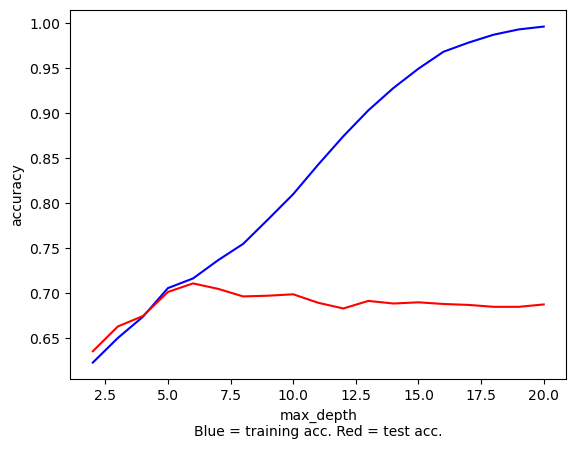

In [13]:
import matplotlib.pyplot as plt
# Check the model performance for max depth from 2-20, store into two lists that we can plot.
test_score = []
train_score = []
for max_depth in range(2, 21):
    temp_model = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    temp_model.fit(X_train, y_train)
    test_score.append(temp_model.score(X_test, y_test))
    train_score.append(temp_model.score(X_train, y_train))

# Plot max depth hyperparameter values vs training and test accuracy score.
plt.plot(range(2, 21), train_score, 'b', range(2, 21), test_score, 'r')
plt.xlabel('max_depth\nBlue = training acc. Red = test acc.')
plt.ylabel('accuracy')
plt.show()

In [14]:
## Grid SearchCV
from sklearn.model_selection import GridSearchCV
# Define grid search CV parameters.
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 7),
    'min_samples_leaf': range(20, 60, 10)
}

def perform_grid_search(X_train, y_train, X_test, y_test, params, num_folds=10):
    # Instantiate the search class. Pass it the model to use (the DecisionTreeClassifier), and the number of folds.
    cv = GridSearchCV(param_grid=params,
                      estimator=DecisionTreeClassifier(random_state=random_state), cv=num_folds, verbose=1,
                      n_jobs=-1)
    cv.fit(X_train, y_train)

    # Display the accuracy of the best fit model.
    print("Train accuracy:", cv.score(X_train, y_train))
    print("Test accuracy:", cv.score(X_test, y_test))
    # Evaluate the best fit model.
    y_pred = cv.predict(X_test)
    print(classification_report(y_test, y_pred))
    # Display parameters of the best model.
    print(cv.best_params_)
    return cv

perform_grid_search(X_train, y_train, X_test, y_test, params)

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Train accuracy: 0.7099571975670196
Test accuracy: 0.7041513399894903
              precision    recall  f1-score   support

           0       0.69      0.56      0.62      1643
           1       0.71      0.81      0.76      2163

    accuracy                           0.70      3806
   macro avg       0.70      0.69      0.69      3806
weighted avg       0.70      0.70      0.70      3806

{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 50}


,estimator,DecisionTreeC...ndom_state=10)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': range(2, 7), 'min_samples_leaf': range(20, 60, 10)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [15]:
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 6),
    'min_samples_leaf': range(1, 20)
}

In [16]:
cv = perform_grid_search(X_train, y_train, X_test, y_test, params)

Fitting 10 folds for each of 152 candidates, totalling 1520 fits
Train accuracy: 0.7057895922505069
Test accuracy: 0.7015239096163952
              precision    recall  f1-score   support

           0       0.72      0.51      0.59      1643
           1       0.69      0.85      0.76      2163

    accuracy                           0.70      3806
   macro avg       0.71      0.68      0.68      3806
weighted avg       0.70      0.70      0.69      3806

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 15}


In [17]:
model_cv = cv.best_estimator_
# visualize_model(model_cv)

In [18]:
display_feature_importances(model_cv, feature_names)

coupon : 0.39157989021704953
expiration : 0.1540068031139314
Bar : 0.10281098023706303
CoffeeHouse : 0.09857578072618081
destination : 0.07985273480736707
direction_same : 0.07136864647502984
weather : 0.037584813460869664
passanger : 0.023519290369106216
Restaurant20To50 : 0.013372937632612287
RestaurantLessThan20 : 0.01306164196344282
has_children : 0.006987948186247442
temperature : 0.004482916252081966
CarryAway : 0.0027956165590178137
income : 0.0
occupation : 0.0
education : 0.0
toCoupon_GEQ25min : 0.0
maritalStatus : 0.0
age : 0.0
gender : 0.0
Number of leaves: 32


In [19]:
print('*****Model parameters******\n', model_cv.get_params(deep=True))
print('Number of leaves in the trained model:', model_cv.get_n_leaves())

*****Model parameters******
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 15, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 10, 'splitter': 'best'}
Number of leaves in the trained model: 32


In [20]:
#ROC
# probability prediction from decision tree
y_pred = model_cv.predict(X_test)
y_pred_proba_dt = model_cv.predict_proba(X_test)
print("Probability produced by decision tree for each class vs actual prediction on TargetB (0 = non-donor, 1 = donor).")
print("You should be able to see the default threshold of 0.5.")
print("(Probs on zero) (probs on one) (prediction made) (label)")

# print top 10
for i in range(20): 
    print(f"{y_pred_proba_dt[i][0]:.13f} {y_pred_proba_dt[i][1]:.13f} {y_pred[i]:<10d} {y_test[i]:10d}")

Probability produced by decision tree for each class vs actual prediction on TargetB (0 = non-donor, 1 = donor).
You should be able to see the default threshold of 0.5.
(Probs on zero) (probs on one) (prediction made) (label)
0.7369146005510 0.2630853994490 0                   1
0.2245614035088 0.7754385964912 1                   1
0.4696132596685 0.5303867403315 1                   1
0.3940594059406 0.6059405940594 1                   0
0.2335164835165 0.7664835164835 1                   1
0.9111111111111 0.0888888888889 0                   0
0.1990521327014 0.8009478672986 1                   0
0.5772357723577 0.4227642276423 0                   1
0.2900856793146 0.7099143206854 1                   1
0.6533864541833 0.3466135458167 0                   1
0.3540669856459 0.6459330143541 1                   1
0.3540669856459 0.6459330143541 1                   0
0.7369146005510 0.2630853994490 0                   1
0.2900856793146 0.7099143206854 1                   1
0.2900856793146 0.

In [21]:
from sklearn.metrics import roc_auc_score
y_pred_proba_dt = model.predict_proba(X_test)
# y_pred_proba_dt_small = model_small.predict_proba(X_test)
y_pred_proba_dt_cv = model_cv.predict_proba(X_test)
roc_index_dt = roc_auc_score(y_test, y_pred_proba_dt[:, 1])
# roc_index_dt_small = roc_auc_score(y_test, y_pred_proba_dt_small[:, 1])
roc_index_dt_cv = roc_auc_score(y_test, y_pred_proba_dt_cv[:, 1])
print("ROC index on test for default model:", roc_index_dt)
# print("ROC index on test for small model:", roc_index_dt_small)
print("ROC index on test for grid search model:", roc_index_dt_cv)

ROC index on test for default model: 0.682889119814824
ROC index on test for grid search model: 0.7420645003712918


In [22]:
from sklearn.metrics import roc_curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt[:,1])

fpr_dt_cv, tpr_dt_cv, thresholds_dt_cv = roc_curve(y_test, y_pred_proba_dt_cv[:,1])

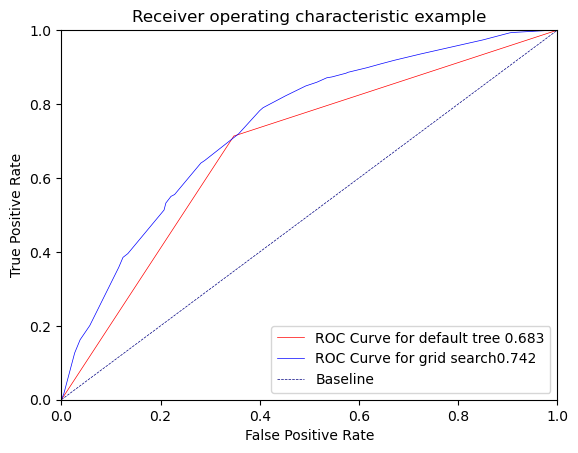

In [23]:
plt.plot(fpr_dt, tpr_dt, label='ROC Curve for default tree {:.3f}'.format(roc_index_dt), color='red', lw=0.5)

plt.plot(fpr_dt_cv, tpr_dt_cv, label='ROC Curve for grid search{:.3f}'.format(roc_index_dt_cv), color='blue', lw=0.5)
plt.plot([0, 1], [0, 1], color='navy', lw=0.5, label='Baseline', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [24]:
#visualize_model(model_cv)

In [25]:
#Saving Model 
import pickle
with open('decision_tree_model.pickle', 'wb') as f:
    pickle.dump([model_cv, roc_index_dt_cv, fpr_dt_cv, tpr_dt_cv], f)